In [5]:
import torch
import torch.nn as nn

from source.runge_preprocessing import y_train, x_train_scaled, ETA_VALUES, LAMBDA_VALUES, x_train_scaled, y_train, x_test, y_test, x, y, x_test_scaled
import source.activation_functions as activations_functions
#from source.cost_functions import mse
from source.cost_functions import class_mse_loss #, class_binary_cros_entropy, class_binary_cros_entropy
from source.utils import neural_network_loop, create_activations_layderdim, pytorch_loop
from source.neural_network import NN
from source.plotting import plot_heatmap, plot_runges


# Settings for this task



In [6]:
# Settings for this task

ITERATIONS = 2000

RMSprop_MOMENTUM = 0.9

BETA1_ADAM = 0.9
BETA2_ADAM = 0.999

L1 = 0.0001
L2 = 0.0001

VERBOSE = False
SHOW_PLOT = True
SAVE_FIGURE = True

OPTIMIZER = 'ADAM'
ACTIVATION_FUNC = 'RELU'

SAVE_FIGURE = True
SHOW_PLOT = True

RUNGE_HIDDEN = (50,100)

ETA_VALUES = 0.001
LAMBDA_VALUES = 0.001


# Pytorch with FFNN

Using data from runge_preprocessing

#### Note that layers for Pytorch must match own implementation

In [7]:
# Defining Pytorch model

# Convert to Pytorch tensors
x_train_scaled_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_scaled_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# ReLU activation function and (50, 100) hidden layer
model= nn.Sequential(
            nn.Linear(1,50),
            nn.ReLU(),
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )



Epoch 0, Loss: 0.192466
Epoch 100, Loss: 0.012264
Epoch 200, Loss: 0.009687
Epoch 300, Loss: 0.009503
Epoch 400, Loss: 0.009449
Epoch 500, Loss: 0.009434
Epoch 600, Loss: 0.009419
Epoch 700, Loss: 0.009408
Epoch 800, Loss: 0.009400
Epoch 900, Loss: 0.009400
Epoch 1000, Loss: 0.009396
Epoch 1100, Loss: 0.009404
Epoch 1200, Loss: 0.009393
Epoch 1300, Loss: 0.009391
Epoch 1400, Loss: 0.009393
Epoch 1500, Loss: 0.009391
Epoch 1600, Loss: 0.009402
Epoch 1700, Loss: 0.009392
Epoch 1800, Loss: 0.009392
Epoch 1900, Loss: 0.009391


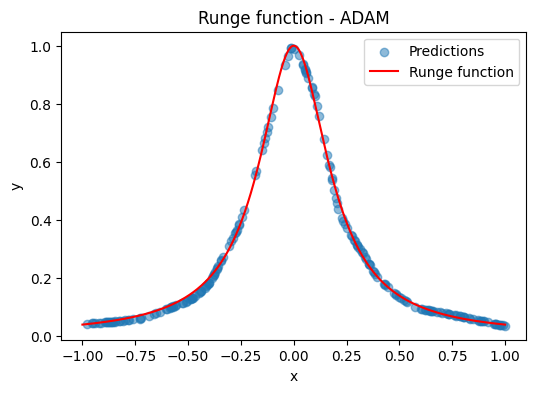

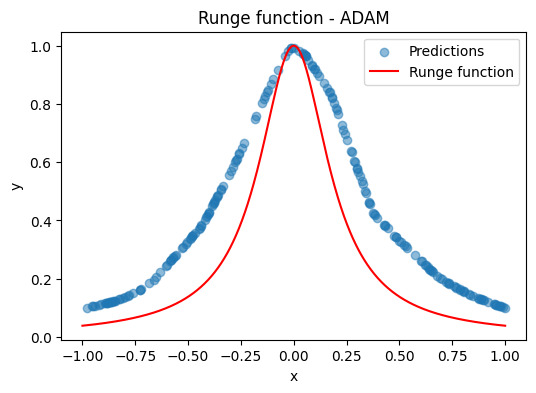

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

cost_func = nn.MSELoss()

optimizer_adam = optim.Adam(model.parameters(), lr=ETA_VALUES, betas = (BETA1_ADAM, BETA2_ADAM), weight_decay=L2)  # weight_decay closely elated to L2

for epoch in range(ITERATIONS):
    optimizer_adam.zero_grad()
    outputs = model(x_train_scaled_tensor)
    loss = cost_func(outputs, y_train_tensor)

    loss.backward()
    optimizer_adam.step()

    if epoch % 100 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

# Predict
with torch.no_grad():
    predictions = model(x_test_scaled_tensor)
    predictions2 = model(x_test_tensor)

mse_test = cost_func(predictions, y_test_tensor)

plot_runges(x, y, x_test, predictions.numpy(), title=f'Runge function - {OPTIMIZER}')#
plot_runges(x, y, x_test, predictions2.numpy(), title=f'Runge function - {OPTIMIZER}')#

In [9]:
# Plotting heatmaps - Pytorch

#plot_heatmap(result_torch, title=f'Runge function - {OPTIMIZER}', heat_metric='MSE', filename=f'part_c-heatmap_pytorch', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# Runges
#min_row = result_torch.loc[result_torch['MSE'].idxmin()]
#predictions = min_row['Predictions'] # find predictions for lowest mse
#plot_runges(x, y, x_test, predictions, title=f'Runge function - {OPTIMIZER}', filename=f'part_c-runges_pytorch', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# SKLEARN implementation of FFNN

In [10]:
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression

from sklearn.metrics import mean_squared_error
import autograd.numpy as np 
from source.runge_preprocessing import NP_RANDOM_SEED, x_train_scaled, x_test_scaled

# Set up a shared random number generator
rng = np.random.RandomState(NP_RANDOM_SEED)


# Create and train the FFNN model
model = MLPRegressor(hidden_layer_sizes=(50, 100), 
                     activation='relu',
                     solver='adam',
                     learning_rate_init=ETA_VALUES,
                     max_iter=ITERATIONS,
                     random_state=rng)

model.fit(x_train_scaled, y_train)

# Predict and evaluate
y_pred = model.predict(x_test_scaled)
mse = mean_squared_error(y_test, y_pred)

print(f"Test MSE: {mse:.4f}")

Test MSE: 0.0127


c:\Users\brumor\python_env\4155\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1771: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


# Own implementation

In [11]:
# Defining different activation functions and layers, and creating list and dimension to use in own FFNN code

# Activation output always linear with regression
ACTIVATION_FUNCTION_OUTPUT = activations_functions.linear
ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE = activations_functions.linear_derivative

if ACTIVATION_FUNC=='sigmoid':
    ACTIVATION_FUNCTION = activations_functions.sigmoid
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.sigmoid_derivative
elif ACTIVATION_FUNC=='RELU':
    ACTIVATION_FUNCTION = activations_functions.RELU
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.RELU_derivative
elif ACTIVATION_FUNC=='LRELU':
    ACTIVATION_FUNCTION = activations_functions.LRELU
    ACTIVATION_FUNCTION_DERIVATIVE = activations_functions.LRELU_derivative

activations, activations_derivative, _dim = create_activations_layderdim(ACTIVATION_FUNCTION, ACTIVATION_FUNCTION_DERIVATIVE, ACTIVATION_FUNCTION_OUTPUT, ACTIVATION_FUNCTION_OUTPUT_DERIVATIVE, RUNGE_HIDDEN, y_train, x_train_scaled)

print(ACTIVATION_FUNC)

RELU


In [ ]:
from source.cost_functions import class_mse_loss
import source.schedulers as schedulers


cost_fn = class_mse_loss(l1=L1, l2=L2)   # --> lambda values

OPTIMIZER = schedulers.ADAM(rho=BETA1_ADAM, rho2=BETA2_ADAM, eta=ETA_VALUES)

all_rows_as_batches = x_train_scaled.shape[0]

nn_test = NN(_dim, activations, activations_derivative, cost_object=cost_fn)
epoch_scores, predictions  = nn_test.fit(X=x_train_scaled, t=y_train, X_val=x_test_scaled, t_val=y_test, epochs=ITERATIONS, scheduler=OPTIMIZER, batches=all_rows_as_batches)
plot_runges(x, y, x_test, predictions)
print(epoch_scores)



L1 and L2 term
0.0001
0.0001
Using scheduler: ADAM 


In [ ]:
# Plotting heatmaps - own code

#plot_heatmap(result_own, title=f'Runge function - {OPTIMIZER}', heat_metric='MSE', filename=f'part_c-heatmap_{RUNGE_HIDDEN}_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)

# Print best MSE 
#min_row = result_own.loc[result_own['MSE'].idxmin()]
#predictions = result_own.loc[result_own['MSE'].idxmin(), 'Predictions']
#plot_runges(x, y, x_test, predictions, title=f'Runge function - {OPTIMIZER}',filename=f'part_c-heatmap_{RUNGE_HIDDEN}_{OPTIMIZER}', show_plot=SHOW_PLOT, save_image=SAVE_FIGURE)


# Comparing gradients from own implementation and autograd

In [ ]:
# custom imports
from source.neural_network import NN

In [ ]:
import source.schedulers as schedulers
from source.runge_preprocessing import x_test, y_test

runge_NN = NN(_dim, activations, activations_derivative, cost_object=cost_fn)
runge_NN.compare_gradients(X = x_train_scaled, targets = y_train)

